### Face Detection using PCA

Using PCA mechanism to correctly assign the face images to persons on the [Yale Face Dataset](https://vismod.media.mit.edu/vismod/classes/mas622-00/datasets/). Download the training data and testing data in this link.

#### Assignment 1 (4 scores): Implement PCA using Numpy.

In [75]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from pathlib import Path

In [76]:
class PCA:
    def __init__(self, d):
        self.d = d
    
    def fit(self, X):
        cov = (X.T @ X)
        
        eigenvalues, eigenvectors = np.linalg.eigh(cov)
        
        max_abs_idx = np.argmax(np.abs(eigenvectors), axis=0)
        signs = np.sign(eigenvectors[max_abs_idx, range(eigenvectors.shape[1])])
        eigenvectors *= signs
        eigenvectors = eigenvectors.T
        
        eigen_pair = [
            (np.abs(eigenvalues[i]), eigenvectors[i, :])
            for i in range(eigenvectors.shape[0])
        ]

        eigen_pair.sort(key=lambda x: x[0], reverse=True)
        
        eigenvalues = np.array([i[0] for i in eigen_pair])
        eigenvectors = np.array([i[1] for i in eigen_pair])
        
        self.principle_values = eigenvalues[:self.d]
        self._w = eigenvectors[:self.d]
        
    def transform(self, X):
        return X @ self._w.T
        
        

#### Assignment 2 (4 scores):
- Reading the training images.
- Approximating the Principle Space having **20 dimensions**.
- Visualize the base of this Principle Space.

In [77]:
def load_data(path, img_size=(64, 64)):
    X = []
    y = []
    
    for person in os.listdir(path):
        if person == 'test':
            continue
        for img in os.listdir(os.path.join(path, person)):
            img_path = os.path.join(path, person, img)
            img = cv2.imread(img_path, 0)
            img = cv2.resize(img, img_size)
            X.append(img.flatten())
            y.append(person)
    
    return np.array(X), np.array(y)

X, y = load_data('yalefaces/yalefaces')

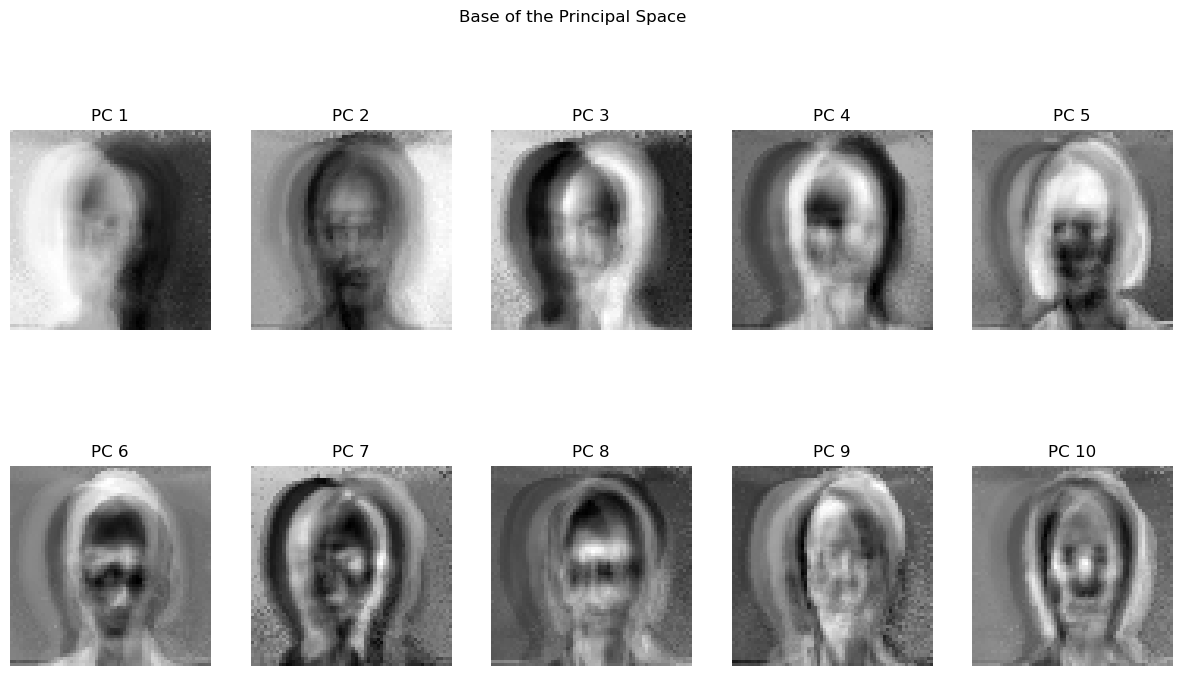

In [ ]:
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)
X = (X - mean) / std
pca = PCA(20)
pca.fit(X)
X = pca.transform(X)
H, W = 64, 64

plt.figure(figsize=(15,8))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(pca._w[i].reshape(H, W), cmap='gray')
    plt.title(f"PC {i+1}")
    plt.axis('off')

plt.suptitle("Base of the Principal Space")
plt.show()

#### Assignment 3 (2 scores): 
- Assign persons to the face images in testing data.
- Evaluate the accuracy of this face recognition system.

In [84]:
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def test(test_dir):
    y_true = []
    y_pred = []
    for img in os.listdir(test_dir):
        img_path = os.path.join(test_dir, img)
        img = cv2.imread(img_path, 0)
        img = cv2.resize(img, (H, W))
        img = img.flatten()
        img = (img - mean) / std
        img = pca.transform(img)
        
        sims = [cosine_similarity(img, x) for x in X]
        
        indx_pred = np.argmax(sims)
        y_pred.append(y[indx_pred])
        path = Path(img_path)
        label = path.stem
        y_true.append(label)
    y_pred = np.array([str(x) for x in y_pred])
    return y_true, y_pred
        
y_true, y_pred = test('yalefaces/yalefaces/test')  
print(f"Accuracy: {np.sum(y_true == y_pred) / len(y_pred)}")
        

Accuracy: 0.8
